<a href="https://colab.research.google.com/github/mohd-Khan-01/LLM_from_Scratch/blob/main/chapter2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone --depth 1 https://github.com/rasbt/LLMs-from-scratch.git

Cloning into 'LLMs-from-scratch'...
remote: Enumerating objects: 398, done.
remote: Counting objects: 100% (398/398), done.
remote: Compressing objects: 100% (319/319), done.
remote: Total 398 (delta 105), reused 225 (delta 66), pack-reused 0 (from 0)
Receiving objects: 100% (398/398), 2.00 MiB | 11.29 MiB/s, done.
Resolving deltas: 100% (105/105), done.


In [2]:
!pip install tiktoken torch --quiet

In [3]:
from importlib.metadata import version

print("torch version:", version("torch"))
print("tiktoken version:", version("tiktoken"))

torch version: 2.10.0+cpu
tiktoken version: 0.12.0


In [4]:
import os
import requests

if not os.path.exists("the-verdict.txt"):
  url=(   "https://raw.githubusercontent.com/rasbt/"
        "LLMs-from-scratch/main/ch02/01_main-chapter-code/"
        "the-verdict.txt"
  )
  file_path="the-verdict.txt"

  response=requests.get(url,timeout=30)
  response.raise_for_status()
  with open(file_path,"wb") as f:
    f.write(response.content)


In [5]:
with open("the-verdict.txt","r",encoding="utf-8") as f:
  raw_text=f.read()
print("total number of character :",len(raw_text))
print(raw_text[:99])

total number of character : 20479
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


okay.. so till now we have successfully loaded the dataset now the next step is to tokenize the dataset.
lets develope a simple tokenizer that we can apply later to the above dataset.

the following regular expression will split on whitespaces


In [6]:
import re
text="hello everyone, this is a test."
result=re.split(r"(\s)",text)
print(result)

['hello', ' ', 'everyone,', ' ', 'this', ' ', 'is', ' ', 'a', ' ', 'test.']


its working fine but we need to split commas and period ,so lets modify the re to do that as well


In [7]:
result=re.split(r'([,.]|\s)',text)
print(result)

['hello', ' ', 'everyone', ',', '', ' ', 'this', ' ', 'is', ' ', 'a', ' ', 'test', '.', '']


as we can see that this create an empty strings which is the spaces between the word lets remove them

In [8]:
result=[item for item in result if item.strip()]
print(result)

['hello', 'everyone', ',', 'this', 'is', 'a', 'test', '.']


now this looks pretty good but lets handle other types of pucntuation also like "?" etc

In [9]:
text="hello world. -- is this a test ?"
result = re.split(r'([,.:;?_!"()\']|--|\s)', text)
result=[item.strip() for item in result if item.strip()]
print(result)

['hello', 'world', '.', '--', 'is', 'this', 'a', 'test', '?']


In [10]:
preprocessed=re.split(r'([,.:;?_!"()\']|--|\s)', raw_text)
preprocessed=[item.strip() for item in preprocessed if item.strip()]
print(preprocessed[:30])

['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '--', 'though', 'a', 'good', 'fellow', 'enough', '--', 'so', 'it', 'was', 'no', 'great', 'surprise', 'to', 'me', 'to', 'hear', 'that', ',', 'in']


In [11]:
#lers calculate the number of tokens
print(len(preprocessed))

4690


# Converting tokens into token IDs

Next, we can covert the text tokens into token IDs that we can process via embedding layers.

In [12]:
all_words = sorted(set(preprocessed))
vocab_size = len(all_words)
print(vocab_size)

1130


In [13]:
vocab={token:integer for integer,token in enumerate(all_words)}


first 50 vocab


In [14]:
for i , item in enumerate(vocab.items()):
  print(item)
  if i>=50:
    break

('!', 0)
('"', 1)
("'", 2)
('(', 3)
(')', 4)
(',', 5)
('--', 6)
('.', 7)
(':', 8)
(';', 9)
('?', 10)
('A', 11)
('Ah', 12)
('Among', 13)
('And', 14)
('Are', 15)
('Arrt', 16)
('As', 17)
('At', 18)
('Be', 19)
('Begin', 20)
('Burlington', 21)
('But', 22)
('By', 23)
('Carlo', 24)
('Chicago', 25)
('Claude', 26)
('Come', 27)
('Croft', 28)
('Destroyed', 29)
('Devonshire', 30)
('Don', 31)
('Dubarry', 32)
('Emperors', 33)
('Florence', 34)
('For', 35)
('Gallery', 36)
('Gideon', 37)
('Gisburn', 38)
('Gisburns', 39)
('Grafton', 40)
('Greek', 41)
('Grindle', 42)
('Grindles', 43)
('HAD', 44)
('Had', 45)
('Hang', 46)
('Has', 47)
('He', 48)
('Her', 49)
('Hermia', 50)


In [15]:
class SimpleTokenizerV1:
  def __init__(self,vocab):
    self.str_to_int=vocab
    self.int_to_str={i:s for s,i in vocab.items()}

  def encode(self,text):
    preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', text)
    preprocessed=[
        item.strip() for item in preprocessed if item.strip()
        ]
    ids=[self.str_to_int[s] for s in preprocessed]
    return ids

  def decode(self,ids):
    text = " ".join([self.int_to_str[i] for i in ids])
    # Replace spaces before the specified punctuations
    text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)
    return text

The encode function turns text into token IDs
The decode function turns token IDs back into text

In [16]:
tokenizer=SimpleTokenizerV1(vocab)
text = """"It's the last he painted, you know,"
           Mrs. Gisburn said with pardonable pride."""
ids=tokenizer.encode(text)
print(ids)

[1, 56, 2, 850, 988, 602, 533, 746, 5, 1126, 596, 5, 1, 67, 7, 38, 851, 1108, 754, 793, 7]


In [17]:
tokenizer.decode(ids)

'" It\' s the last he painted, you know," Mrs. Gisburn said with pardonable pride.'

# **2.4 Adding special context tokens**

It's useful to add some "special" tokens for unknown words and to denote the end of a text
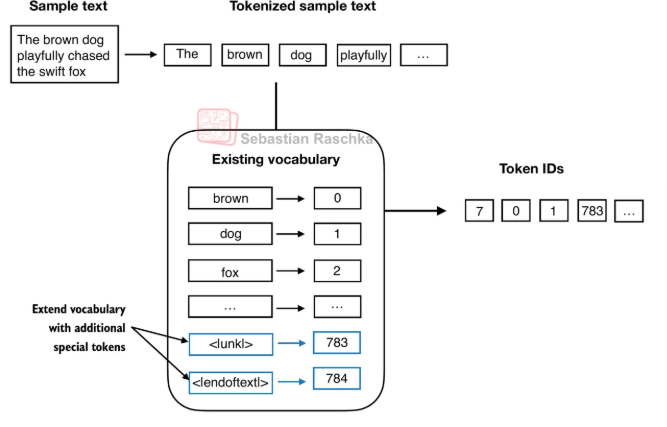

Some tokenizers use special tokens to help the LLM with additional context

Some of these special tokens are

[BOS] (beginning of sequence) marks the beginning of text
[EOS] (end of sequence) marks where the text ends (this is usually used to concatenate multiple unrelated texts, e.g., two different Wikipedia articles or two different books, and so on)
[PAD] (padding) if we train LLMs with a batch size greater than 1 (we may include multiple texts with different lengths; with the padding token we pad the shorter texts to the longest length so that all texts have an equal length)
[UNK] to represent words that are not included in the vocabulary

Note that GPT-2 does not need any of these tokens mentioned above but only uses an <|endoftext|> token to reduce complexity

The <|endoftext|> is analogous to the [EOS] token mentioned above

GPT also uses the <|endoftext|> for padding (since we typically use a mask when training on batched inputs, we would not attend padded tokens anyways, so it does not matter what these tokens are)

GPT-2 does not use an <UNK> token for out-of-vocabulary words; instead, GPT-2 uses a byte-pair encoding (BPE) tokenizer, which breaks down words into subword units which we will discuss in a later section

We use the <|endoftext|> tokens between two independent sources of text:



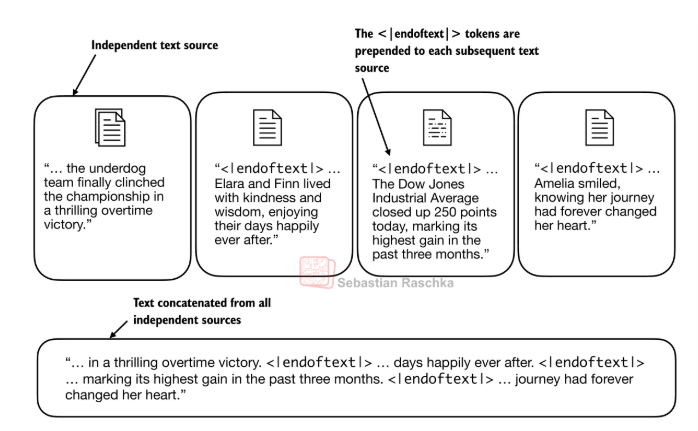

In [18]:
# @title
text="hello,do you . is this a test?"
tokenizer.encode(text)

KeyError: 'hello'

we got the error becuase "hello" doesn't exist in our vocab

so to deal with such we will be add special token "<|unk|>" to represent the unknown word in vocab

Since we are already extending the vocabulary, let's add another token called "<|endoftext|>" which is used in GPT-2 training to denote the end of a text (and it's also used between concatenated text, like if our training datasets consists of multiple articles, books, etc.)

In [20]:
all_tokens=sorted(list(set(preprocessed)))
all_tokens.extend(["<|endoftext|>","<|unk|>"])
vocab={token:integer for integer,token in enumerate(all_tokens)}

In [21]:
len(vocab.items())

1132

In [22]:
for i,item in enumerate(list(vocab.items())[-5:]):
  print(item)

('younger', 1127)
('your', 1128)
('yourself', 1129)
('<|endoftext|>', 1130)
('<|unk|>', 1131)


Now we need to adjust the tokenizer so it knows when and how to use the new tokens

In [23]:
class SimpleTokenizerV2:
  def __init__(self,vocab):
    self.str_to_int=vocab
    self.int_to_str={i:s for s,i in vocab.items()}

  def encode(self,text):
    preprocessed=re.split(r'([,.:;?_!"()\']|--|\s)', text)
    preprocessed=[item.strip()for item in preprocessed if item.strip()]
    preprocessed=[
        item if item in self.str_to_int
        else "<|unk|>" for item in preprocessed
    ]
    ids=[self.str_to_int[s] for s in preprocessed]
    return ids

  def decode(self,ids):
    text = " ".join([self.int_to_str[i] for i in ids])
    # Replace spaces before the specified punctuations
    text = re.sub(r'\s+([,.:;?!"()\'])', r'\1', text)
    return text



let's try to tokenize text with this new tokenizer

In [24]:
tokenizer=SimpleTokenizerV2(vocab)
text1="hello, do you like tea?"
text2="In the sunlit terraces of the palaces"

text="<|endoftext|>".join((text1,text2))
print(text)

hello, do you like tea?<|endoftext|>In the sunlit terraces of the palaces


In [25]:
ids=tokenizer.encode(text)

In [26]:
tokenizer.decode(ids)

'<|unk|>, do you like tea? <|unk|> the sunlit terraces of the <|unk|>'

# BytePair encoding

GPT-2 used BytePair encoding (BPE) as its tokenizer
it allows the model to break down words that aren't in its predefined vocabulary into smaller subword units or even individual characters, enabling it to handle out-of-vocabulary words

For instance, if GPT-2's vocabulary doesn't have the word "unfamiliarword," it might tokenize it as ["unfam", "iliar", "word"] or some other subword breakdown, depending on its trained BPE merges
The original BPE tokenizer can be found here: https://github.com/openai/gpt-2/blob/master/src/encoder.py

In this chapter, we are using the BPE tokenizer from OpenAI's open-source tiktoken library, which implements its core algorithms in Rust to improve computational performance


Sebastian raschka created a notebook in the "https://github.com/rasbt/LLMs-from-scratch/blob/8447d70b185dfd34ad60a1cc9e6d10e92314e907/ch02/02_bonus_bytepair-encoder" that compares these two implementations side-by-side (tiktoken was about 5x faster on the sample text)

In [27]:
import importlib
import tiktoken

print("tiktoken version:",importlib.metadata.version("tiktoken"))

tiktoken version: 0.12.0


In [28]:
tokenizer = tiktoken.get_encoding("gpt2")

In [29]:
text = (
    "Hello, do you like tea? <|endoftext|> In the sunlit terraces"
     "of someunknownPlace."
)

integers=tokenizer.encode(text,allowed_special={"<|endoftext|>"})
print(integers)



[15496, 11, 466, 345, 588, 8887, 30, 220, 50256, 554, 262, 4252, 18250, 8812, 2114, 1659, 617, 34680, 27271, 13]


In [30]:
strings=tokenizer.decode(integers)

In [31]:
strings

'Hello, do you like tea? <|endoftext|> In the sunlit terracesof someunknownPlace.'

BPE tokenizer breakdown unknown words into subwords and individual characters

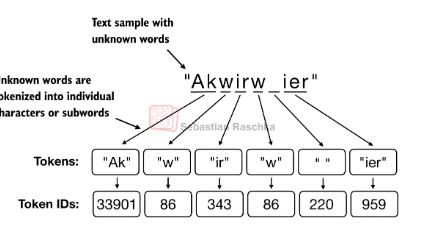

# DataSampling with sliding windows

we train llms to predict next word at a time ,so we want to prepare the training data accordingly where the next word in a sequence represent the target to predict

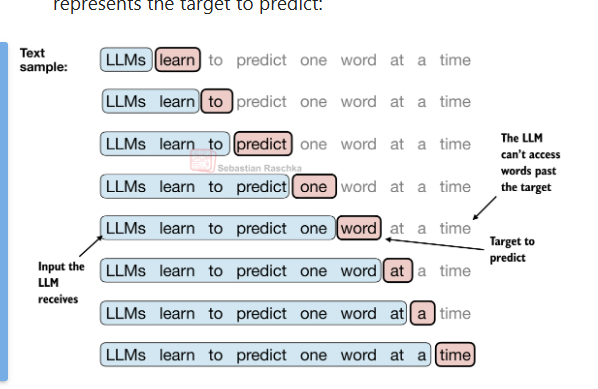

In [32]:
enc_text=tokenizer.encode(raw_text)
print(len(enc_text))

5145


For each text chunk, we want the inputs and targets
Since we want the model to predict the next word, the targets are the inputs shifted by one position to the right

In [33]:
enc_sample=enc_text[50:]

In [34]:
context_size = 4

x = enc_sample[:context_size]
y = enc_sample[1:context_size+1]

print(f"x: {x}")
print(f"y:      {y}")

x: [290, 4920, 2241, 287]
y:      [4920, 2241, 287, 257]


X are the inputs and y is the outputs

We will take care of the next-word prediction in a later chapter after we covered the attention mechanism


For now, we implement a simple data loader that iterates over the input dataset and returns the inputs and targets shifted by one

In [35]:
import torch

we will be using a simple dataloader function to implement the sliding window approach

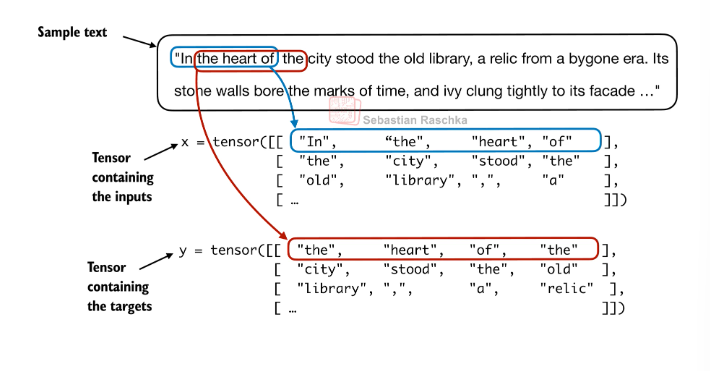

In [36]:
from torch.utils.data import Dataset,DataLoader

class GPTdatasetV1(Dataset):
  def __init__(self,txt,tokenizer,max_length,stride):
    self.input_ids=[]
    self.target_ids=[]

    #tokenizing the entire text

    token_ids=tokenizer.encode(txt,allowed_special={"<|endoftext|>"})
    assert len(token_ids)>max_length,"Number of tokenized inputs must at least be equal to max_length+1"
    for i in range(0, len(token_ids) - max_length, stride):
      input_chunk = token_ids[i:i + max_length]
      target_chunk = token_ids[i + 1: i + max_length + 1]
      self.input_ids.append(torch.tensor(input_chunk))
      self.target_ids.append(torch.tensor(target_chunk))

  def __len__(self):
    return len(self.input_ids)

  def __getitem__(self, idx):
    return self.input_ids[idx], self.target_ids[idx]

In [37]:
def create_dataloader_v1(txt,batch_size=4,max_length=256,stride=128,shuffle=True,drop_last=True,num_workers=0):
  tokenizer=tiktoken.get_encoding("gpt2")
  dataset=GPTdatasetV1(txt,tokenizer,max_length,stride)

  dataloader=DataLoader(
      dataset,
      batch_size=batch_size,
      shuffle=shuffle,
      drop_last=drop_last,
      num_workers=num_workers
  )

  return dataloader

In [38]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()
dataloader = create_dataloader_v1(
    raw_text, batch_size=1, max_length=4, stride=1, shuffle=False
)


In [39]:
data_iter = iter(dataloader)
first_batch = next(data_iter)
print(first_batch)

[tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])]


In [40]:
dataloader = create_dataloader_v1(raw_text, batch_size=8, max_length=4, stride=4, shuffle=False)

data_iter = iter(dataloader)
inputs, targets = next(data_iter)
print("Inputs:\n", inputs)
print("\nTargets:\n", targets)

Inputs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Targets:
 tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])


##Creating token embeddings

->okay so the data is almost ready for llm
->now let's embed the tokens in a continous vector representation
using an embedding layer
->Usually ,these embedding layers are part of the llm itself and are updated (trained) during model training

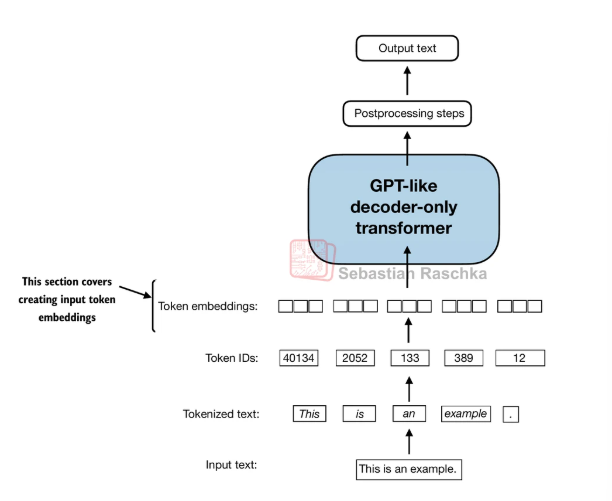

suppose we have the tokens ids 2,3,5 and 1

In [41]:
inputs_ids=torch.tensor([2,3,5,1])

For the sake of simplicity, suppose we have a small vocabulary of only 6 words and we want to create embeddings of size 3:

In [42]:
vocab_size=6
output_dim=3
torch.manual_seed(123)
embedding_layer=torch.nn.Embedding(vocab_size,output_dim)

#this would result in a 6x3 matrix

In [43]:
print(embedding_layer.weight)

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


now lets convert the id 3 into a 3 dim vector

In [44]:
print(embedding_layer(torch.tensor([3])))

tensor([[-0.4015,  0.9666, -1.1481]], grad_fn=<EmbeddingBackward0>)


In [46]:
print(embedding_layer(inputs_ids))

tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)


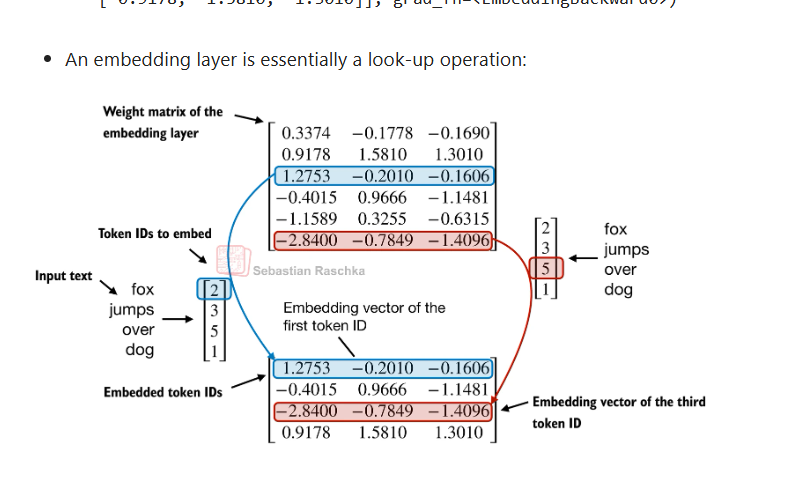

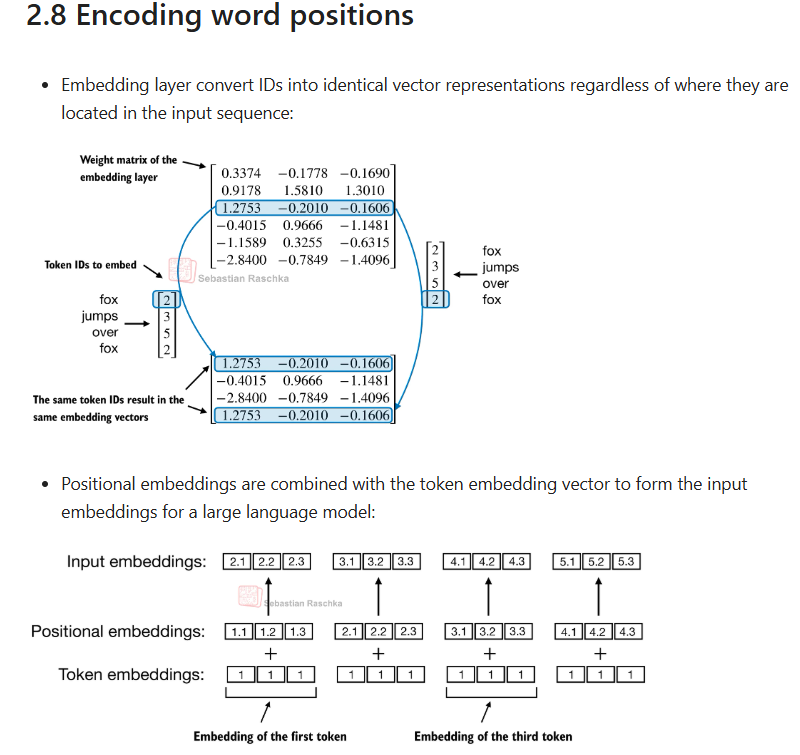

the bpe has  vocabulary of 50,257
suppose we want to encode the input tokens into a 256 dim-vector representation

In [48]:
vocab_size=50257
output_dim=256
token_embedding_layer=torch.nn.Embedding(vocab_size,output_dim)


If we have a batch size of 8 with 4 tokens each, this results in a 8 x 4 x 256 tenso

In [49]:
max_length=4
data_loader=create_dataloader_v1(
    raw_text,batch_size=8,max_length=max_length,stride=max_length,shuffle=False
)
data_iter=iter(dataloader)
inputs,targtes=next(data_iter)

In [50]:

print("Token IDs:\n", inputs)
print("\nInputs shape:\n", inputs.shape)

Token IDs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Inputs shape:
 torch.Size([8, 4])


In [52]:
token_embeddings=token_embedding_layer(inputs)
print(token_embeddings.shape)


torch.Size([8, 4, 256])


In [53]:
print(token_embeddings)

tensor([[[ 0.4913,  1.1239,  1.4588,  ..., -0.3995, -1.8735, -0.1445],
         [ 0.4481,  0.2536, -0.2655,  ...,  0.4997, -1.1991, -1.1844],
         [-0.2507, -0.0546,  0.6687,  ...,  0.9618,  2.3737, -0.0528],
         [ 0.9457,  0.8657,  1.6191,  ..., -0.4544, -0.7460,  0.3483]],

        [[ 1.5460,  1.7368, -0.7848,  ..., -0.1004,  0.8584, -0.3421],
         [-1.8622, -0.1914, -0.3812,  ...,  1.1220, -0.3496,  0.6091],
         [ 1.9847, -0.6483, -0.1415,  ..., -0.3841, -0.9355,  1.4478],
         [ 0.9647,  1.2974, -1.6207,  ...,  1.1463,  1.5797,  0.3969]],

        [[-0.7713,  0.6572,  0.1663,  ..., -0.8044,  0.0542,  0.7426],
         [ 0.8046,  0.5047,  1.2922,  ...,  1.4648,  0.4097,  0.3205],
         [ 0.0795, -1.7636,  0.5750,  ...,  2.1823,  1.8231, -0.3635],
         [ 0.4267, -0.0647,  0.5686,  ..., -0.5209,  1.3065,  0.8473]],

        ...,

        [[-1.6156,  0.9610, -2.6437,  ..., -0.9645,  1.0888,  1.6383],
         [-0.3985, -0.9235, -1.3163,  ..., -1.1582, -1.13

GPT-2 uses absolute position embeddings,we just create another embedding layer

In [54]:
context_length=max_length
pos_embedding_layer=torch.nn.Embedding(context_length,output_dim)


In [56]:
pos_embedding_layer.weight

Parameter containing:
tensor([[ 1.7375, -0.5620, -0.6303,  ..., -0.2277,  1.5748,  1.0345],
        [ 1.6423, -0.7201,  0.2062,  ...,  0.4118,  0.1498, -0.4628],
        [-0.4651, -0.7757,  0.5806,  ...,  1.4335, -0.4963,  0.8579],
        [-0.6754, -0.4628,  1.4323,  ...,  0.8139, -0.7088,  0.4827]],
       requires_grad=True)

In [57]:
pos_embeddings = pos_embedding_layer(torch.arange(max_length))
print(pos_embeddings.shape)

torch.Size([4, 256])


To create the input embeddings used in an LLM, we simply add the token and the positional embeddings:

In [58]:

input_embeddings = token_embeddings + pos_embeddings
print(input_embeddings.shape)


torch.Size([8, 4, 256])


In the initial phase of the input processing workflow, the input text is segmented into separate tokens
Following this segmentation, these tokens are transformed into token IDs based on a predefined vocabulary:

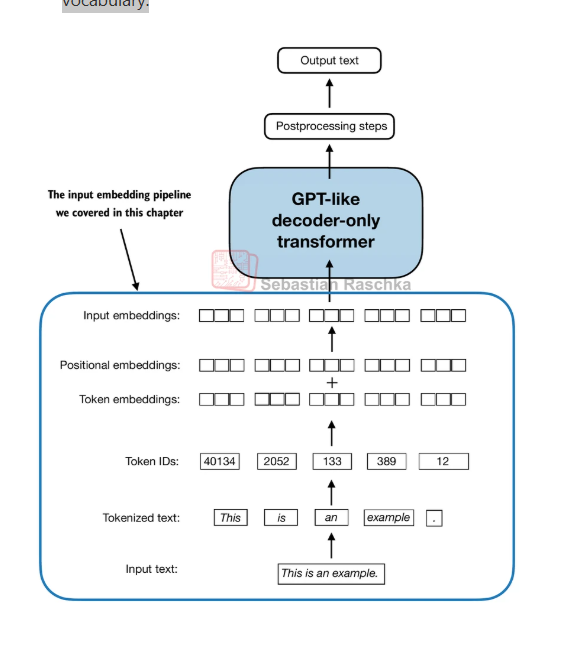